## 2025 빅콘테스트 AI 데이터 경진대회
팀 DA4U (송휘린, 강예서, 김서정, 문찬우) \
마감일: 10월 24일 (금)

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
pd.set_option('display.max_columns', None)

In [85]:
df1 = pd.read_csv("dataset/big_data_set1_f.csv", encoding="cp949")
df2 = pd.read_csv("dataset/big_data_set2_f.csv", encoding="cp949")
df3 = pd.read_csv("dataset/big_data_set3_f.csv", encoding="cp949")

In [86]:
print("df1:", df1.shape)
print("df2:", df2.shape)
print("df3:", df3.shape)

df1: (4185, 9)
df2: (86590, 15)
df3: (86590, 17)


In [87]:
print("\n컬럼명:", df1.columns.tolist())
# 결측치 요약
print("\n결측치 개수:\n", df1.isna().sum())

# 기본 통계
print("\n기본 통계:\n", df1.describe(include="all"))


컬럼명: ['ENCODED_MCT', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM', 'HPSN_MCT_BZN_CD_NM', 'ARE_D', 'MCT_ME_D']

결측치 개수:
 ENCODED_MCT              0
MCT_BSE_AR               0
MCT_NM                   0
MCT_BRD_NUM           3643
MCT_SIGUNGU_NM           0
HPSN_MCT_ZCD_NM          0
HPSN_MCT_BZN_CD_NM    1047
ARE_D                    0
MCT_ME_D              4058
dtype: int64

기본 통계:
        ENCODED_MCT          MCT_BSE_AR MCT_NM MCT_BRD_NUM MCT_SIGUNGU_NM  \
count         4185                4185   4185         542           4185   
unique        4185                2938   3386         287              1   
top     16184E93D9  서울특별시 성동구 왕십리로 410   성수**      커피전문점2         서울 성동구   
freq             1                  73     31          20           4185   
mean           NaN                 NaN    NaN         NaN            NaN   
std            NaN                 NaN    NaN         NaN            NaN   
min            NaN                 NaN    NaN       

In [88]:
df1.columns = [
    "코드",
    "기준면적",
    "가맹점명",
    "브랜드코드",
    "지역",
    "업종",
    "상권",
    "개설일",
    "폐업일"
]

df2.columns = [
    "코드",
    "기준년월",
    "운영개월수",
    "매출금액",
    "매출건수",
    "유니크고객수",
    "객단가",
    "취소율",
    "배달매출비율",
    "동종매출금액%",
    "동종매출건수%",
    "동종매출순위%",
    "동일상권매출순위%",
    "동종해지가맹점%",
    "동일상권해지가맹점비중"
]

df3.columns = [
    "코드",
    "기준년월",
    "남20대이하",
    "남30대",
    "남40대",
    "남50대",
    "남60대이상",
    "여20대이하",
    "여30대",
    "여40대",
    "여50대",
    "여60대이상",
    "재방문고객",
    "신규고객",
    "거주이용고객",
    "직장이용고객",
    "유동인구이용고객"
]

In [89]:
print(df1.head())
print(df2.head())  
print(df3.head())

           코드        기준면적  가맹점명 브랜드코드      지역   업종   상권       개설일  폐업일
0  16184E93D9  서울 성동구 마장동  성우**   NaN  서울 성동구  축산물  마장동  20130320  NaN
1  4D039EA8B7  서울 성동구 마장동  대보**   NaN  서울 성동구  축산물  마장동  20131122  NaN
2  0074C4990A  서울 성동구 마장동  대용**   NaN  서울 성동구  축산물  마장동  20140512  NaN
3  68308F2746  서울 성동구 마장동  통일**   NaN  서울 성동구  축산물  마장동  20151124  NaN
4  4117EDDE9C  서울 성동구 마장동  한울**   NaN  서울 성동구  축산물  마장동  20151211  NaN
           코드    기준년월     운영개월수                매출금액                매출건수  \
0  000F03E44A  202404  4_50-75%            5_75-90%            5_75-90%   
1  000F03E44A  202312  4_50-75%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
2  002816BA73  202404  2_10-25%            3_25-50%            4_50-75%   
3  002816BA73  202411  2_10-25%            3_25-50%            4_50-75%   
4  002816BA73  202406  2_10-25%            4_50-75%            4_50-75%   

               유니크고객수                 객단가             취소율    배달매출비율  동종매출금액%  \
0            5_75-90%            5_75-90%  

In [90]:
# df2와 df3를 (가맹점코드, 기준년월)로 병합
#   - 교집합만 원하면 how="inner", 한쪽에만 있는 월도 살리고 싶으면 how="outer"
df23 = pd.merge(
    df2, df3,
    on=["코드", "기준년월"],
    how="outer",
    suffixes=("_x", "_y")
)

print(df23.head())

           코드    기준년월     운영개월수                매출금액                매출건수  \
0  000F03E44A  202301  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   
1  000F03E44A  202302  5_75-90%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
2  000F03E44A  202303  5_75-90%  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)   
3  000F03E44A  202304  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   
4  000F03E44A  202305  5_75-90%  6_90%초과(하위 10% 이하)            5_75-90%   

               유니크고객수                 객단가      취소율    배달매출비율  동종매출금액%  \
0            5_75-90%            4_50-75%  1_상위1구간 -999999.9      0.5   
1  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)      NaN -999999.9      0.0   
2  6_90%초과(하위 10% 이하)  6_90%초과(하위 10% 이하)      NaN -999999.9      0.0   
3            5_75-90%            3_25-50%  1_상위1구간 -999999.9      1.3   
4            5_75-90%  6_90%초과(하위 10% 이하)  1_상위1구간 -999999.9      0.0   

   동종매출건수%  동종매출순위%  동일상권매출순위%  동종해지가맹점%  동일상권해지가맹점비중  남20대이하     남30대  남40대  \
0      1.1     95.3       75.1

In [66]:
# 0) 키 타입 맞추기(중요)
df23['코드'] = df23['코드'].astype(str)
df1['코드']  = df1['코드'].astype(str)

# 1) df1에서 코드가 중복이라면 먼저 정리
df1_u = df1.sort_values(['코드','폐업일','개설일']).drop_duplicates('코드', keep='last')

df = df1.merge(df23, on="코드", how="right", validate="1:m")



In [93]:
# 백분율 구간 치환 
mapping = {'1_10%이하':'10%', '2_10-25%':'25%','3_25-50%':'50%','4_50-75%':'75%','5_75-90%':'90%',   
       '6_90%초과(하위 10% 이하)':'100%',  }
       
cols = ['운영개월수', '매출금액', '매출건수', '유니크고객수', '객단가']

for c in cols:
    df[c] = df[c].map(mapping).fillna(df[c])


In [94]:
mapping2 = {
    '1_상위1구간': '상위1',
    '2_상위2구간': '상위2',
    '3_상위3구간': '상위3',
    '4_상위4구간': '상위4',
    '5_상위5구간': '상위5',
    '6_상위6구간(하위1구간)': '상위6'
}

df['취소율'] = df['취소율'].replace(mapping2)


In [95]:
import numpy as np
df = df.replace(-999999.9, np.nan)

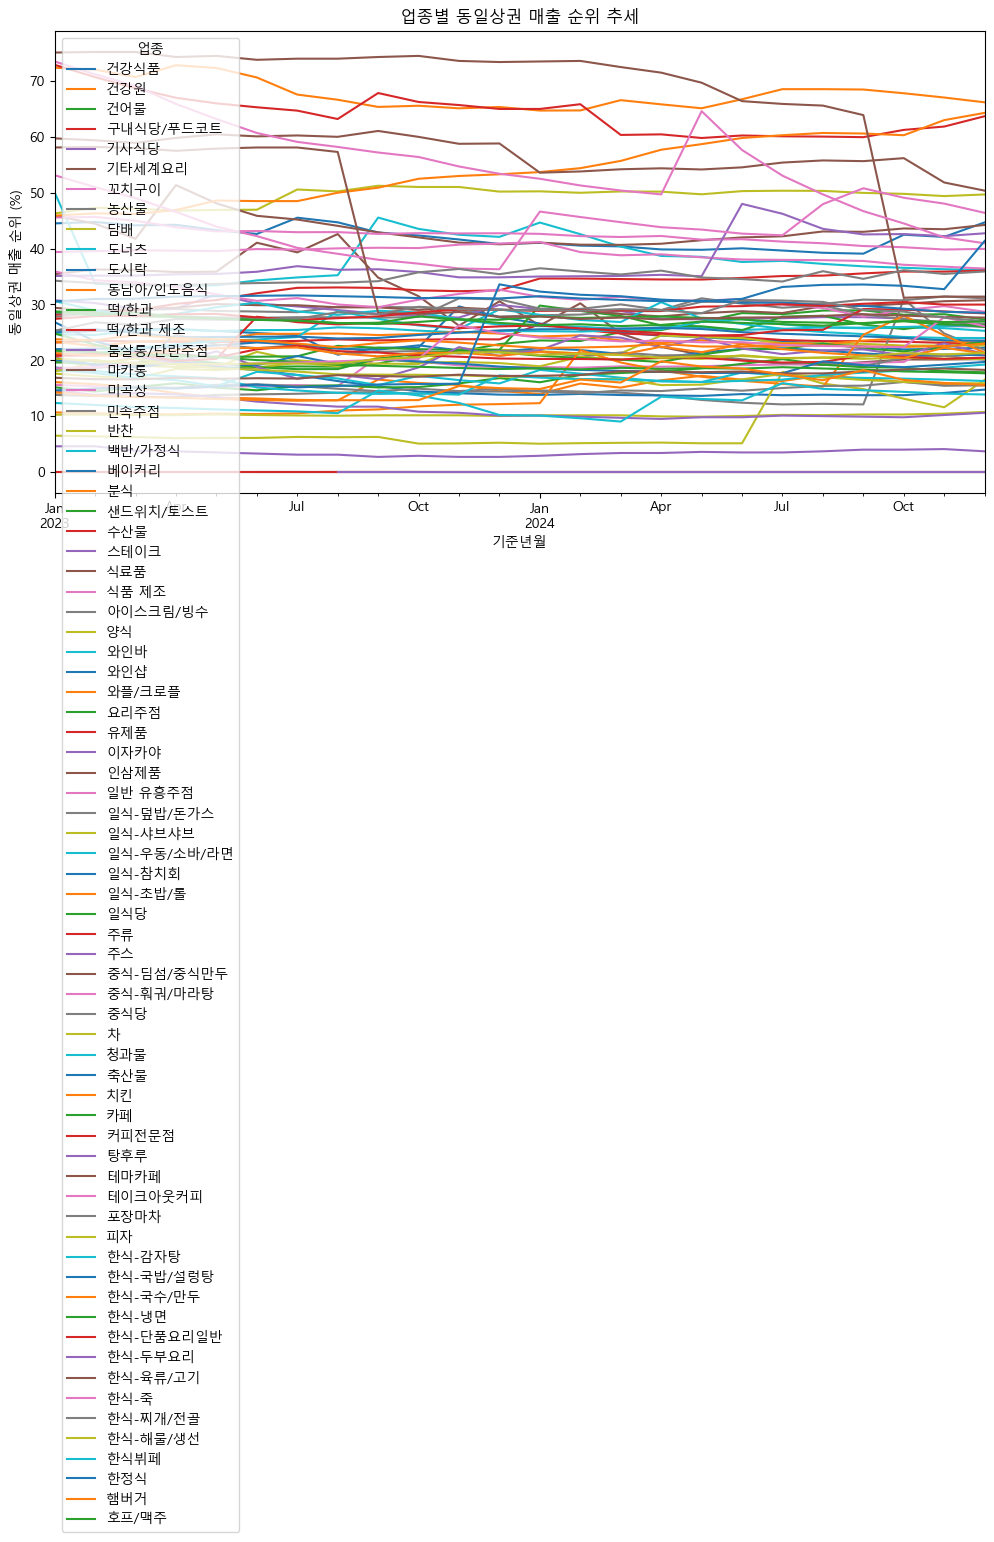

In [101]:
# 윈도우: 맑은 고딕으로 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 1. 업종별·월별 평균 동일상권매출순위% 집계
pivot_df = df.groupby(['기준년월','업종'])['동일상권매출순위%'].mean().reset_index()

# 2. 피벗 테이블로 변환
pivot_table = pivot_df.pivot(index='기준년월', columns='업종', values='동일상권매출순위%')

# 3. 라인 차트 그리기
pivot_table.plot(figsize=(12,6))
plt.title("업종별 동일상권 매출 순위 추세")
plt.xlabel("기준년월")
plt.ylabel("동일상권 매출 순위 (%)")
plt.legend(title="업종")
plt.show()


In [112]:
col = "동종매출건수%"

# 숫자형 변환 (혹시 문자열 섞였을 때 대비)
df[col] = pd.to_numeric(df[col], errors='coerce')

# 이상치 행 전체 추출
outliers = df[df[col] > 2000]

print("이상치 행 개수:", len(outliers))
display(outliers.head(10))   # Jupyter이면 display(), 콘솔이면 print()




이상치 행 개수: 91


,코드,기준면적,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,기준년월,운영개월수,매출금액,매출건수,유니크고객수,객단가,취소율,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객,기준년월_dt,z_score
1294,02FE4FD151,서울특별시 성동구 왕십리로4길 28-2,로우*****,NaN,서울 성동구,커피전문점,뚝섬,20180814,NaN,2024-04-01,50%,10%,10%,10%,90%,상위2,NaN,360.7,2109.6,5.1,9.4,17.5,7.8,13.0385,19.4020,7.9210,3.1595,0.9790,16.2615,24.1980,9.8790,3.9405,1.2210,36.97,10.90,16.8,25.1,58.1,2024-04-01,8.619729
4304,0C25C3B746,서울특별시 성동구 아차산로 113,성수*******,샌드위치/토스트2,서울 성동구,샌드위치/토스트,성수,20230130,NaN,2024-04-01,90%,10%,10%,10%,75%,상위5,18.9,738.1,2008.9,0.9,2.2,17.5,8.0,18.8325,15.9960,5.1615,4.5570,1.9995,21.6675,18.4040,5.9385,5.2430,2.3005,32.06,8.32,20.0,22.5,57.5,2024-04-01,8.176255
6914,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-01-01,50%,10%,10%,10%,90%,상위2,NaN,354.7,3460.7,4.3,7.1,19.8,8.0,13.4620,13.6144,11.2776,8.7884,3.6576,13.0380,13.1856,10.9224,8.5116,3.5424,35.44,6.70,16.1,26.6,57.3,2023-01-01,14.569859
6915,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-02-01,50%,10%,10%,10%,90%,상위3,NaN,383.9,3417.9,4.3,7.0,20.2,7.9,13.1805,13.6350,11.3120,8.7365,3.6865,12.9195,13.3650,11.0880,8.5635,3.6135,35.11,7.35,15.1,26.4,58.5,2023-02-01,14.381372
6916,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-03-01,50%,10%,10%,10%,90%,상위2,NaN,376.4,3333.3,4.2,7.1,21.1,8.6,12.8500,13.6500,11.1500,8.7500,3.6500,12.8500,13.6500,11.1500,8.7500,3.6500,35.29,7.28,14.5,26.2,59.4,2023-03-01,14.008800
6917,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-04-01,50%,10%,10%,10%,90%,상위3,NaN,382.0,3465.0,4.0,6.8,21.9,9.0,12.7710,13.5630,10.8405,8.6625,3.6630,13.0290,13.8370,11.0595,8.8375,3.7370,35.13,7.69,14.1,27.5,58.4,2023-04-01,14.588796
6918,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-05-01,50%,25%,10%,10%,90%,상위2,NaN,274.1,2595.0,4.0,6.7,22.7,8.8,12.6936,13.5300,10.6764,8.6592,3.6408,13.1064,13.9700,11.0236,8.9408,3.7592,34.69,5.91,14.9,24.1,61.0,2023-05-01,10.757390
6919,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-06-01,50%,25%,10%,10%,90%,상위2,NaN,288.2,2717.0,3.9,6.7,22.3,8.7,12.5874,13.4136,10.4976,8.5536,3.5478,13.3126,14.1864,11.1024,9.0464,3.7522,34.40,5.72,15.2,26.0,58.8,2023-06-01,11.294667
6920,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-07-01,50%,25%,10%,10%,90%,상위2,NaN,267.4,2687.1,3.9,6.7,21.7,8.7,12.5280,13.2480,10.2720,8.4480,3.5040,13.5720,14.3520,11.1280,9.1520,3.7960,34.27,6.21,15.0,24.1,60.9,2023-07-01,11.162990
6921,147EC9E665,서울특별시 성동구 아차산로 100,어묵**,NaN,서울 성동구,식료품,성수,20180822,NaN,2023-08-01,50%,25%,10%,10%,90%,상위2,NaN,244.2,2314.5,3.9,6.6,21.2,8.9,12.5236,13.2406,10.1336,8.4606,3.4416,13.6764,14.4594,11.0664,9.2394,3.7584,34.46,5.08,15.7,25.8,58.5,2023-08-01,9.522091


In [ ]:
print(df.head())
df

           코드                 기준면적  가맹점명 브랜드코드      지역          업종  상권  \
0  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
1  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
2  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
3  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
4  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**   NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   

        개설일  폐업일       기준년월 운영개월수  매출금액  매출건수 유니크고객수   객단가  취소율  배달매출비율  \
0  20220225  NaN 2023-01-01   90%  100%   90%    90%   75%  상위1     NaN   
1  20220225  NaN 2023-02-01   90%  100%  100%   100%  100%  NaN     NaN   
2  20220225  NaN 2023-03-01   90%  100%  100%   100%  100%  NaN     NaN   
3  20220225  NaN 2023-04-01   90%  100%   90%    90%   50%  상위1     NaN   
4  20220225  NaN 2023-05-01   90%  100%   90%    90%  100%  상위1     NaN   

   동종매출금액%  동종매출건수%  동종매출순위%  동일상권매출순위%  동종해지가맹점%  동일상권해지가맹점비중  남20대이하  \
0      0.5      1.1     95.3  

,코드,기준면적,가맹점명,브랜드코드,지역,업종,상권,개설일,폐업일,기준년월,운영개월수,매출금액,매출건수,유니크고객수,객단가,취소율,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객,기준년월_dt
0,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,2023-01-01,90%,100%,90%,90%,75%,상위1,NaN,0.5,1.1,95.3,75.1,15.8,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,100.00,0.0,0.0,100.0,2023-01-01
1,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,2023-02-01,90%,100%,100%,100%,100%,NaN,NaN,0.0,0.0,95.2,75.2,16.3,8.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,NaN,NaN,NaN,2023-02-01
2,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,2023-03-01,90%,100%,100%,100%,100%,NaN,NaN,0.0,0.0,95.0,75.2,16.7,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,NaN,NaN,NaN,2023-03-01
3,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,2023-04-01,90%,100%,90%,90%,50%,상위1,NaN,1.3,1.0,94.5,74.3,17.3,8.2,0.0000,36.0000,0.0000,36.0000,0.0000,0.0000,14.0000,0.0000,14.0000,0.0000,0.00,50.00,0.0,100.0,0.0,2023-04-01
4,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,중식-딤섬/중식만두,뚝섬,20220225,NaN,2023-05-01,90%,100%,90%,90%,100%,상위1,NaN,0.0,1.0,94.6,74.5,17.9,8.0,0.0000,47.1569,0.0000,23.5431,0.0000,0.0000,19.5431,0.0000,9.7569,0.0000,0.00,33.33,0.0,0.0,100.0,2023-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86585,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,2024-08-01,50%,25%,50%,50%,50%,상위1,NaN,294.8,361.7,2.8,7.6,16.6,8.0,22.0955,20.0625,6.4200,3.7450,1.2305,19.2045,17.4375,5.5800,3.2550,1.0695,9.60,6.24,16.0,20.8,63.2,2024-08-01
86586,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,2024-09-01,50%,10%,50%,25%,25%,상위5,NaN,424.3,456.2,2.7,7.3,16.9,8.3,22.1400,20.4660,6.3180,3.9420,1.1880,18.8600,17.4340,5.3820,3.3580,1.0120,9.62,8.07,21.5,16.2,62.3,2024-09-01
86587,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,2024-10-01,50%,25%,50%,25%,50%,상위1,NaN,333.6,386.6,2.7,7.3,16.9,8.1,21.4799,20.6804,6.0762,3.8376,1.2259,18.8201,18.1196,5.3238,3.3624,1.0741,10.27,7.48,16.8,16.0,67.2,2024-10-01
86588,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,꼬치구이,성수,20160704,NaN,2024-11-01,50%,25%,50%,25%,25%,상위1,NaN,355.0,407.1,2.7,7.3,16.6,8.2,21.2464,21.2464,6.2872,4.0650,1.3550,17.9536,17.9536,5.3128,3.4350,1.1450,10.28,7.96,17.9,19.5,62.6,2024-11-01


In [106]:
df.describe()

,개설일,폐업일,기준년월,배달매출비율,동종매출금액%,동종매출건수%,동종매출순위%,동일상권매출순위%,동종해지가맹점%,동일상권해지가맹점비중,남20대이하,남30대,남40대,남50대,남60대이상,여20대이하,여30대,여40대,여50대,여60대이상,재방문고객,신규고객,거주이용고객,직장이용고객,유동인구이용고객,기준년월_dt
count,8.659000e+04,2.334000e+03,86590,29245.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,65171.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84586.000000,84947.000000,84947.000000,79263.000000,79263.000000,79263.000000,86590
mean,2.017494e+07,2.024871e+07,2024-01-05 02:25:18.826653952,27.786917,134.503306,152.312380,31.184643,24.070313,16.187137,8.526055,11.525991,13.374123,10.081328,11.076727,8.998239,10.868017,11.300895,7.854147,8.067192,6.854265,25.344110,9.832667,34.882047,13.179571,51.939785,2024-01-05 02:25:18.826653952
min,1.990023e+07,2.023010e+07,2023-01-01 00:00:00,0.000000,-70.000000,0.000000,0.100000,0.000000,0.000000,4.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023-01-01 00:00:00
25%,2.015031e+07,2.025070e+07,2023-07-01 00:00:00,3.200000,25.200000,22.100000,9.900000,1.300000,14.100000,7.900000,4.136175,7.920125,5.215200,4.730000,1.609400,2.509200,5.530875,4.377600,4.271850,1.458725,14.430000,5.100000,14.300000,3.400000,35.300000,2023-07-01 00:00:00
50%,2.019091e+07,2.025072e+07,2024-01-01 00:00:00,14.800000,82.500000,81.700000,23.900000,18.900000,17.000000,8.600000,9.890050,12.503700,9.440150,8.994100,5.034100,7.057500,9.887350,6.787800,6.703750,3.495500,24.410000,6.760000,31.500000,8.600000,50.000000,2024-01-01 00:00:00
75%,2.022042e+07,2.025080e+07,2024-07-01 00:00:00,45.300000,181.700000,199.600000,48.200000,39.200000,18.700000,9.300000,16.055900,18.160300,13.404750,15.114000,12.291000,15.558000,15.924500,9.828000,10.210800,7.599675,33.970000,8.850000,51.700000,18.800000,67.400000,2024-07-01 00:00:00
max,2.024122e+07,2.025082e+07,2024-12-01 00:00:00,111.200000,4300.900000,7059.800000,100.000000,99.600000,59.100000,13.900000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2024-12-01 00:00:00
std,5.724404e+04,4.974240e+03,NaN,30.455040,167.981671,227.070665,25.253279,22.843491,3.876532,1.350034,9.928668,8.597113,7.887185,9.862084,11.566516,11.299233,8.497852,6.818896,7.439765,10.897236,15.120843,14.384539,24.636196,14.128362,23.885167,NaN
